In [2]:
import torch

print("GPU 사용 가능:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU 이름:", torch.cuda.get_device_name(0))

GPU 사용 가능: False


# 미션 6 X-Ray 사진으로 폐렴 여부를 구분하는 분류(Classification) 모델을 만들기

## 데이터 로드
> **목적:** 데이터를 불러오고 구성을 확인한다.
>
> **참고:** kaggle 제공 자료 - https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
- device 설정
- 학습 위치 확인 (GPU 무조껀 필요 - colap연결)
- train: 훈련 데이터, test: 테스트 데이터, val: 검증 데이터 다운로드 받기
- 데이터셋 로드 생성
- 데이터 확인 - 각각 몇장인지, 어떤 싸이즈인지
- print 해서 각각 이미지 확인
## EDA
> **목적** 데이터 특성과 문제점을 파악하고 전처리, 평가 방법의 근거를 생각한다.
>
> **참고** 강사님자료 PRACTICE-1, HTML
- 전부 가장 많은 클래서로 예측했을 떄의 정확도 확인
- 실제 배열 읽기 size, channel, dtupe, range
- 학습 데이터에서 정상·폐렴 이미지를 각각 15장씩 랜덤으로 보기
- 클래스별로 5장씩 3회 시각화하여 밝기, 구도, 잘림 등 보기
- 검증 데이터는 16장 전체를 확인
- 관찰한 특징과 추가 확인이 필요한 사항을 기록
- size -> 어떤 싸이즈로 맞추면 좋을지 사전에 생각하기
- train, val, test에 중복 확인(데이터 누수 방지)
- 검증 데이터가 16장으로 적다는 점을 확인
- 검증 점수의 변동 가능성을 고려하여 데이터 분할 방식을 설정
- 테스트 데이터는 최종 평가용으로 유지
## 전처리
> **목적** 학습하기 좋은 상태를 만든다.
>
> **참고** 강의자료 PRACTICE-1, CodeIt baseline 사용
- 데이터 전처리 정의 
- 이미 분리된 학습·검증·테스트 데이터의 전처리 방법을 정의한다.
- 학습 데이터에만 랜덤 크롭과 회전으로 데이터 증강을 적용한다.
- 모든 데이터에 텐서 변환과 정규화를 적용한다.
- 랜덤 크롭과 회전을 증강 후보로 검토한다.
- 변환된 이미지를 확인한 후 적용 여부와 강도를 결정한다.
## 모델 학습
> **목적** 4가지 모델 중 가장 정확도가 높은 모델을 찾기
>
> **참고** CodeIt baseline 사용
- Transfer Learning - 코드잇 제공자료 활용
- Fine-Tuning 적용하기
- Custom CNN, ResNet18 Frozen, Partial Fine-Tuning, Full Fine-Tuning 도 함께 적용하여 비교하기
- 각 실험에서 검증 성능이 가장 좋은 모델을 별도 파일로 저장
- 실험 설정과 학습·검증 지표를 기록하여 비교
- bar-plot으로 최종 성능비교
- 모델별 학습 곡선을 2×2 배치로 그린다.
- 각 그래프의 가로축은 epoch, 세로축은 loss로 설정
- 각 그래프에 train loss와 val loss 두 선을 표시
- 최종 평가 지표는 막대그래프로 비교
## 예측 - 검증 데이터 사용
## 검증 성능 평가 및 모델 선택
> **목적:** 네 가지 실험의 분류 성능을 비교한다.

- 검증 Accuracy가 가장 높은 시점의 모델을 저장한다.
- Precision, Recall, F1-score도 함께 확인하여 성능을 해석한다.
## 테스트 데이터 최종평가

In [ ]:
# # 미션 6 X-Ray 사진으로 폐렴 여부를 구분하는 분류(Classification) 모델을 만들기

# ## 데이터 로드
# > **목적:** 데이터를 불러오고 구성을 확인한다.
# >
# > **참고:** kaggle 제공 자료 - https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
#완료 - device 설정
#완료 - 학습 위치 확인
#완료 - train: 훈련 데이터, test: 테스트 데이터, val: 검증 데이터 다운로드 받기
#완료 - 데이터셋 로드 생성
# - 데이터 확인 - 각각 몇장인지, 어떤 싸이즈인지
# - print 해서 각각 이미지 확인
# ## EDA
# > **목적** 데이터 특성과 문제점을 파악하고 전처리, 평가 방법의 근거를 생각한다.
# >
# > **참고** 강사님자료 PRACTICE-1, HTML
# - 전부 가장 많은 클래서로 예측했을 떄의 정확도 확인
# - 실제 배열 읽기 size, channel, dtupe, range
# - 학습 데이터에서 정상·폐렴 이미지를 각각 15장씩 랜덤으로 보기
# - 클래스별로 5장씩 3회 시각화하여 밝기, 구도, 잘림 등 보기
# - 검증 데이터는 16장 전체를 확인
# - 관찰한 특징과 추가 확인이 필요한 사항을 기록
# - size -> 어떤 싸이즈로 맞추면 좋을지 사전에 생각하기
# - train, val, test에 중복 확인(데이터 누수 방지)
# - 검증 데이터가 16장으로 적다는 점을 확인
# - 검증 점수의 변동 가능성을 고려하여 데이터 분할 방식을 설정
# - 테스트 데이터는 최종 평가용으로 유지
# ## 전처리
# > **목적** 학습하기 좋은 상태를 만든다.
# >
# > **참고** 강의자료 PRACTICE-1, CodeIt baseline 사용
# - 데이터 전처리 정의 
# - 이미 분리된 학습·검증·테스트 데이터의 전처리 방법을 정의한다.
# - 학습 데이터에만 랜덤 크롭과 회전으로 데이터 증강을 적용한다.
# - 모든 데이터에 텐서 변환과 정규화를 적용한다.
# ## 모델 학습
# > **목적** 4가지 모델 중 가장 정확도가 높은 모델을 찾기
# >
# > **참고** CodeIt baseline 사용
# - Transfer Learning - 코드잇 제공자료 활용
# - Fine-Tuning 적용하기
# - Frozen, Partial Fine-Yuning, Full fine-Tuning 도 함께 적용하여 비교하기
# - 각 실험에서 검증 성능이 가장 좋은 모델을 별도 파일로 저장
# - 실험 설정과 학습·검증 지표를 기록하여 비교
# - bar-plot으로 최종 성능비교
# - 선으로 에폭과 로스 train, val 두가지로 4개 선 그려서 비교
# ## 예측 - 검증 데이터 사용
# ## 검증 성능 평가 및 모델 선택
# > 평가지표는 Accuaracy, Precision, Recall, F1-score 4가지를 활용하 성능비교실시
# ## 테스트 데이터 최종평가

## 데이터 로드

In [1]:
# 캐글 데이터 불러오기

import kagglehub 

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
print("Dataset path:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset path: /kaggle/input/chest-xray-pneumonia


In [2]:
# 어디서 학습할것인가? 학습에 사용할 장치 설정

import torch
import os

# GPU 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu"
"")
print(device)

cpu


In [3]:
# 데이터 로드 준비중 -> 파일경로 확인하는 셸

train_dir = os.path.join(path, "chest_xray", "train")
val_dir = os.path.join(path, "chest_xray", "val")
test_dir = os.path.join(path, "chest_xray", "test")

In [4]:
# 데이터 불러오기

from torchvision import datasets
from torch.utils.data import DataLoader
from torchvision.transforms import v2

transforms = v2.Compose(
    [
        v2.Resize((224, 224)),
        v2.ToImage(),
        v2.ToDtype(dtype=torch.float32, scale=True),
    ]
)

# 데이터셋 로드
train_dataset = datasets.ImageFolder(train_dir, transform=transforms)

# DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 클래스 확인
class_names = train_dataset.classes
print("Class names:", class_names)
print(type(class_names)) # 무엇인가?
print(len(class_names)) # 몇개인가?


Class names: ['NORMAL', 'PNEUMONIA']
<class 'list'>
2


In [5]:
# 안에 들어있는 클래스 수가 2개인걸로 보여서 데이터셋 열어보기

print("데이터 갯수", len(train_dataset))

데이터 갯수 5216


In [6]:
# 데이터 확인 - 각각 몇장인지, 어떤 싸이즈인지

from PIL import Image
import numpy as np

# 학습 데이터셋의 첫 번째 이미지 파일 경로와 정답 번호
image_path, label = train_dataset.samples[0]

# 전처리를 거치지 않은 원본 파일 열기
with Image.open(image_path) as img:
    print("원본 크기(너비, 높이):", img.size)
    print("이미지 모드:", img.mode)  # L: 흑백, RGB: 컬러

    # 이미지를 숫자 배열로 바꾸기
    arr = np.array(img)

print("배열 모양:", arr.shape)      # 흑백: (높이, 너비), RGB: (높이, 너비, 3)
print("자료형:", arr.dtype)         # 숫자를 저장하는 자료형
print("픽셀 최솟값:", arr.min())
print("픽셀 최댓값:", arr.max())

원본 크기(너비, 높이): (2090, 1858)
이미지 모드: L
배열 모양: (1858, 2090)
자료형: uint8
픽셀 최솟값: 0
픽셀 최댓값: 255


| 출력 | 의미 |
|---|---|
| `img.size: (2090, 1858)` | **너비, 높이** 순서 |
| `모드: L` | 밝기만 표현하는 **흑백 1채널** |
| `arr.shape: (1858, 2090)` | 배열에서는 **높이, 너비** 순서 |
| `uint8` | 0~255의 정수를 저장하는 자료형 |
| 최솟값 0, 최댓값 255 | 이 사진에 검정(0)부터 흰색(255)까지 포함됨 |

# **결론 적기** 감상평 금지
>

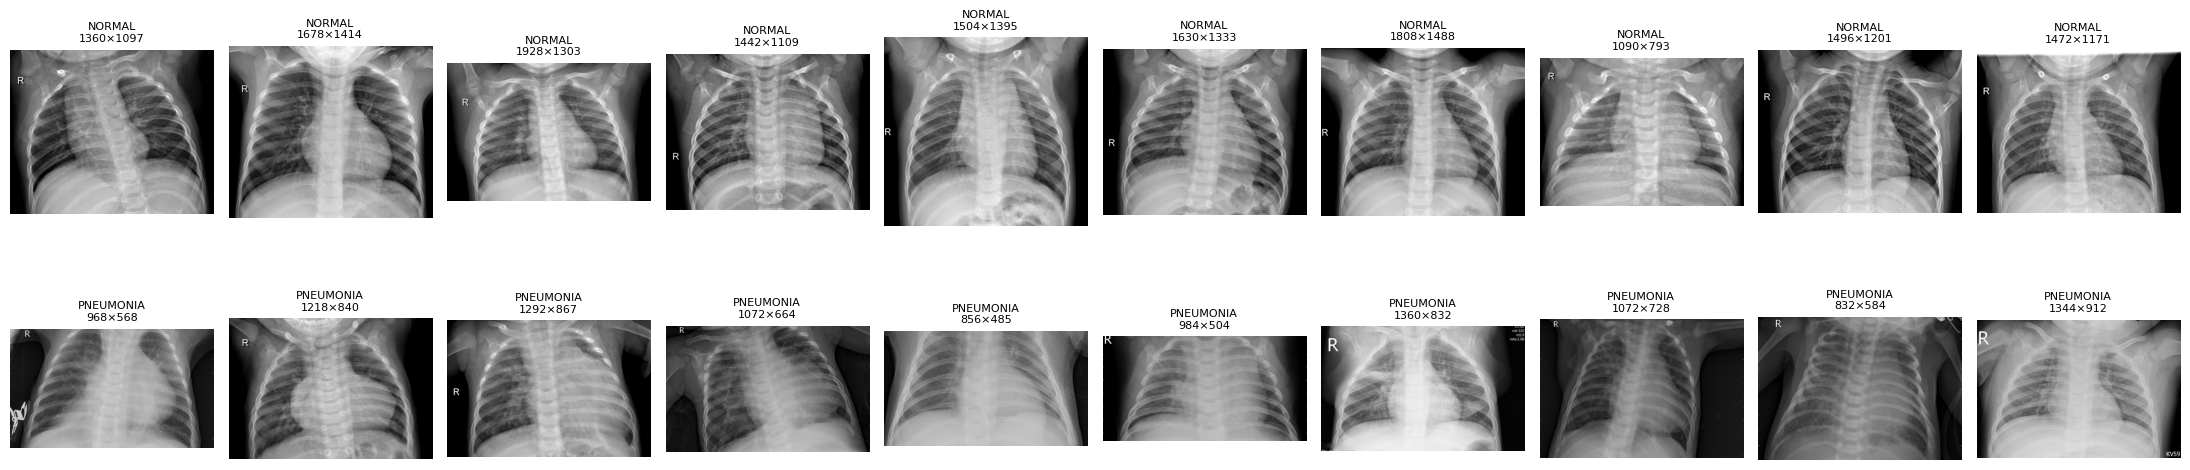

In [7]:
# print 해서 각각 이미지 확인 

import random
import matplotlib.pyplot as plt
from PIL import Image

# 같은 코드를 다시 실행해도 같은 사진을 뽑도록 설정
rng = random.Random(42)

# 2행 × 10열의 그림 칸 만들기
fig, axes = plt.subplots(2, 10, figsize=(22, 6))

for row, class_name in enumerate(["NORMAL", "PNEUMONIA"]):
    class_id = train_dataset.class_to_idx[class_name]

    # 해당 클래스의 이미지 경로만 모으기
    paths = [
        path for path, label in train_dataset.samples
        if label == class_id
    ]

    # 중복 없이 10장 무작위 선택
    selected_paths = rng.sample(paths, 10)

    for col, path in enumerate(selected_paths):
        ax = axes[row, col]  # 사진을 넣을 칸 선택

        # 전처리 전 원본 이미지 열기
        with Image.open(path) as img:
            ax.imshow(img, cmap="gray", vmin=0, vmax=255)
            ax.set_title(f"{class_name}\n{img.width}×{img.height}", fontsize=8)

        ax.axis("off")  # 좌표 눈금 숨기기

plt.tight_layout()
plt.show()

## 그래서 폐렴이라고 어떻게 판단하는가?
> 여기까지 데이터에 대한 정보를 보았는데 그럼 이미지를 보고 우리는 어떻게 판단할 수 있나? 폐렴이라고
>
> README를 보고 이야기 해보자


## EDA

### EDA 실행 안내
이 구간은 앞의 학습 셀을 실행하지 않아도 독립적으로 실행할 수 있다. 원본 이미지 파일은 수정하지 않는다.
로컬에서는 기존 데이터를 사용하고, Colab에서는 앞서 지정한 경로 또는 KaggleHub 캐시를 사용한다.
테스트 데이터는 개수·형식·중복 같은 무결성 확인에만 사용하며, 테스트 이미지 시각화나 모델 평가는 하지 않는다.

**실행 상태:** 아래 출력은 로컬 원본 데이터에서 실행한 EDA 결과이다. GPU 학습 결과가 아니다.

In [1]:
from pathlib import Path
from collections import Counter
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import hashlib
import re
from IPython.display import display

SEED = 42
CLASSES = ["NORMAL", "PNEUMONIA"]
# train/val/test 폴더가 모두 있는 데이터 루트를 찾는다.
candidates = [Path.cwd() / "chest_xray",
              Path("/Users/codeit/CodeIt-ouo/Mission_6/chest_xray")]
if "train_dir" in globals():
    candidates.insert(0, Path(train_dir).parent)
if "path" in globals() and isinstance(path, (str, Path)):
    candidates.extend([Path(path) / "chest_xray", Path(path)])
def is_data_root(folder):
    return all((folder / split / cls).is_dir()
               for split in ["train", "val", "test"] for cls in CLASSES)
DATA_ROOT = next((p for p in candidates if is_data_root(p)), None)
if DATA_ROOT is None:
    import kagglehub
    downloaded = Path(kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia"))
    DATA_ROOT = next((p for p in [downloaded, downloaded / "chest_xray",
                                downloaded / "chest_xray/chest_xray"] if is_data_root(p)), None)
if DATA_ROOT is None:
    raise FileNotFoundError("train/val/test가 있는 chest_xray 경로를 확인하세요.")

# 하위의 중복 데이터 폴더를 재귀 탐색하지 않고 각 클래스 폴더만 읽는다.
records = []
for split in ["train", "val", "test"]:
    for cls in CLASSES:
        for file in sorted((DATA_ROOT / split / cls).iterdir()):
            if file.is_file() and file.suffix.lower() in {".jpg", ".jpeg", ".png"}:
                records.append({"split": split, "class": cls, "file": str(file), "name": file.name})
files = pd.DataFrame(records)
print("EDA 데이터 위치:", DATA_ROOT)
print("전체 이미지:", len(files), "장")

EDA 데이터 위치: /Users/codeit/CodeIt-ouo/Mission_6/chest_xray
전체 이미지: 5856 장


### 1. 클래스 분포와 다수 클래스 기준선
학습 데이터에서 가장 많은 클래스를 정한 뒤 모든 이미지에 그 답만 하는 기준선이다.
검증·테스트에서 유리한 클래스를 새로 고르지 않는다. 이 값은 학습한 모델의 성능이 아니다.

In [2]:
counts = pd.crosstab(files["split"], files["class"]).reindex(["train", "val", "test"])
counts["TOTAL"] = counts.sum(axis=1)
majority_class = counts.loc["train", CLASSES].idxmax()
counts["majority_baseline_pct"] = counts[majority_class] / counts["TOTAL"] * 100
display(counts.round(2))
print("사진을 보지 않고 항상 답할 클래스:", majority_class)
print("기준선이 높더라도 소수 클래스를 전혀 맞히지 못할 수 있다.")

class,NORMAL,PNEUMONIA,TOTAL,majority_baseline_pct
split,,,,
train,1341,3875,5216,74.29
val,8,8,16,50.00
test,234,390,624,62.50


사진을 보지 않고 항상 답할 클래스: PNEUMONIA
기준선이 높더라도 소수 클래스를 전혀 맞히지 못할 수 있다.


### 2. 실제 배열: 크기·채널·자료형·값 범위
각 클래스에서 원본 한 장씩 읽는다. PIL의 size는 (너비, 높이), NumPy shape는 (높이, 너비[, 채널]) 순서다.
전체 원본의 크기와 읽기 오류도 조사해 샘플 관찰을 보완한다. 테스트의 픽셀 통계는 계산하지 않는다.

In [3]:
for cls in CLASSES:
    file = files.query("split == 'train' and `class` == @cls").iloc[0]["file"]
    with Image.open(file) as img:
        arr = np.array(img)
        print(cls, Path(file).name)
        print("size:", img.size, "mode:", img.mode, "channels:", len(img.getbands()))
        print("shape:", arr.shape, "dtype:", arr.dtype, "range:", (arr.min(), arr.max()))
        print("픽셀 평균:", round(float(arr.mean()), 2), "중앙값:", float(np.median(arr)))
        print()

metadata, read_errors = [], []
# 전체를 실제로 디코딩해서 손상 파일 여부를 확인한다.
for row in files.to_dict("records"):
    try:
        with Image.open(row["file"]) as img:
            img.load()
            metadata.append({**row, "width": img.width, "height": img.height,
                             "mode": img.mode, "channels": len(img.getbands())})
    except Exception as error:
        read_errors.append({"file": row["file"], "error": str(error)})
meta = pd.DataFrame(metadata)
print("읽기 성공:", len(meta), "장 / 읽기 오류:", len(read_errors), "장")
if read_errors:
    display(pd.DataFrame(read_errors))
display(meta.groupby(["split", "mode", "channels"]).size().rename("count").to_frame())

count
split mode channels       
test  L    1           624
train L    1          4933
      RGB  3           283
val   L    1            16

NORMAL IM-0115-0001.jpeg
size: (2090, 1858) mode: L channels: 1
shape: (1858, 2090) dtype: uint8 range: (np.uint8(0), np.uint8(255))
픽셀 평균: 128.91 중앙값: 137.0

PNEUMONIA person1000_bacteria_2931.jpeg
size: (1152, 760) mode: L channels: 1
shape: (760, 1152) dtype: uint8 range: (np.uint8(0), np.uint8(255))
픽셀 평균: 114.54 중앙값: 128.0

읽기 성공: 5856 장 / 읽기 오류: 0 장


### 3–4. 학습 이미지: 클래스별 15장, 5장씩 3회
시드를 고정하고 각 클래스에서 중복 없이 15장을 고른다. 각 그림의 윗줄은 정상 5장, 아랫줄은 폐렴 5장이다.
총 3개 그림으로 30장을 확인한다. 확대·잘림 없이 원본을 표시하고 8비트 밝기 기준을 통일한다.

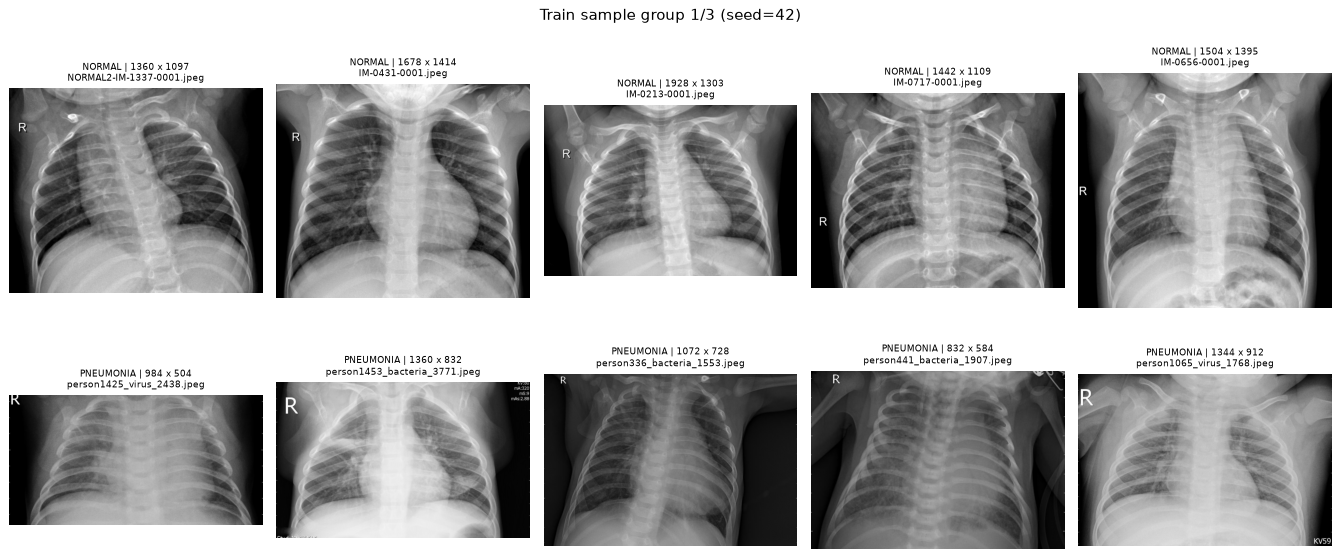

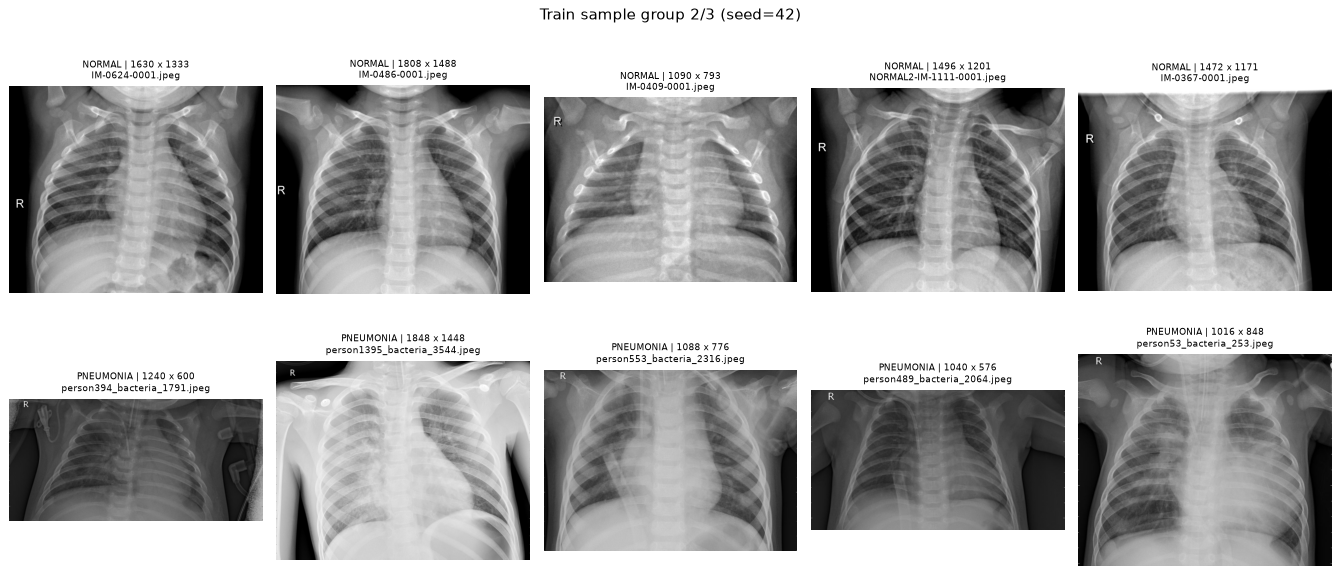

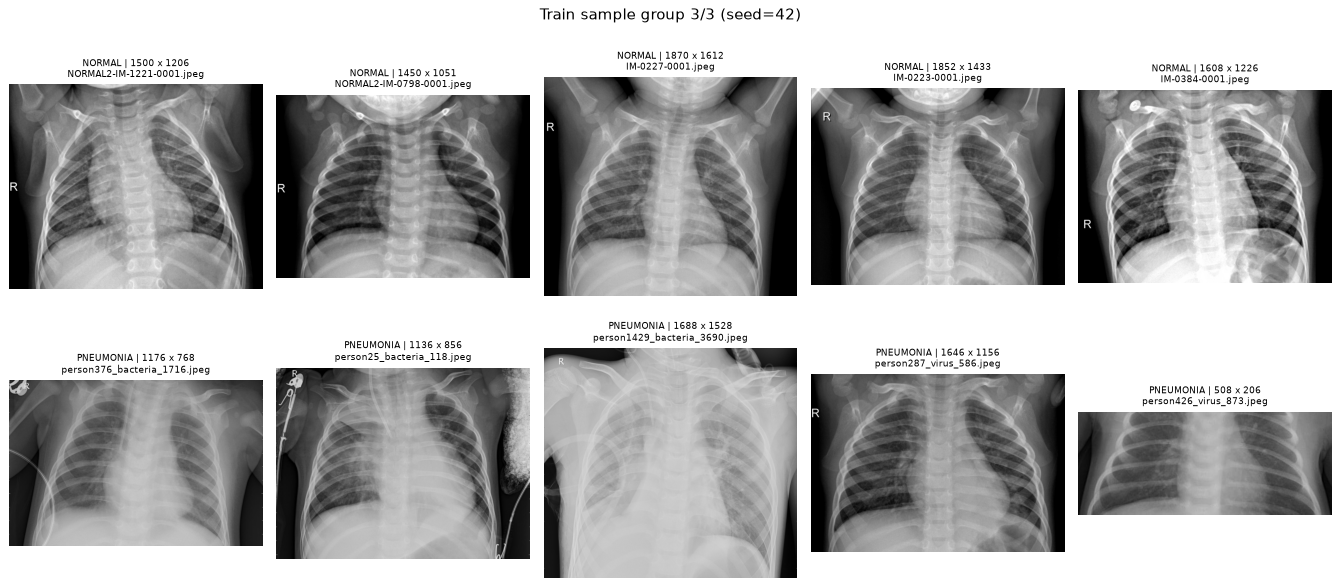

In [4]:
rng = random.Random(SEED)
selected = {}
for cls in CLASSES:
    paths = files.query("split == 'train' and `class` == @cls")["file"].tolist()
    selected[cls] = rng.sample(paths, 15)

for batch in range(3):
    fig, axes = plt.subplots(2, 5, figsize=(15, 7))
    for row, cls in enumerate(CLASSES):
        for col, file in enumerate(selected[cls][batch * 5:(batch + 1) * 5]):
            with Image.open(file) as img:
                axes[row, col].imshow(img, cmap="gray", vmin=0, vmax=255)
                axes[row, col].set_title(f"{cls} | {img.width} x {img.height}\n{Path(file).name}", fontsize=7)
            axes[row, col].axis("off")
    fig.suptitle(f"Train sample group {batch + 1}/3 (seed={SEED})")
    plt.tight_layout()
    plt.show()

### 5. 제공된 검증 이미지 전체 확인
현재 val의 정상·폐렴 이미지를 모두 표시한다. 폴더 개수가 바뀌어도 누락되지 않도록 클래스별로 그린다.

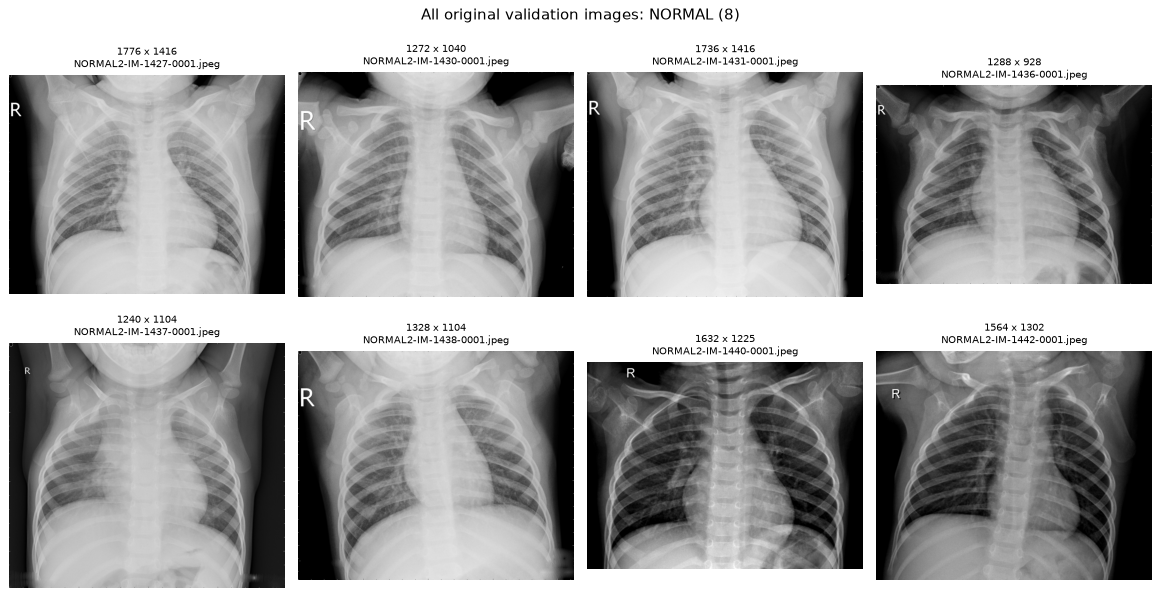

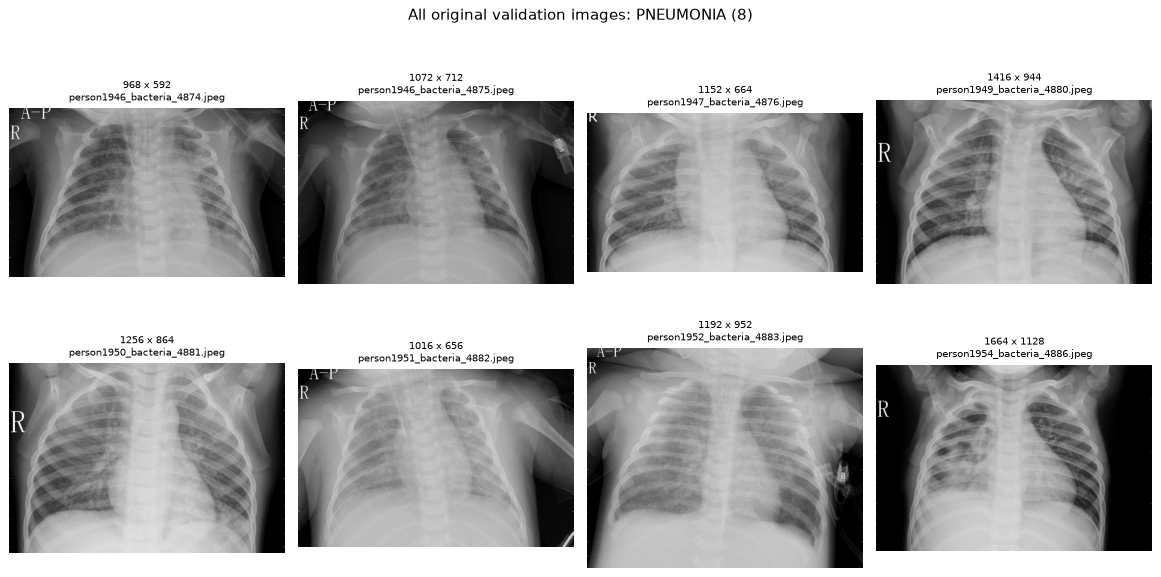

In [5]:
for cls in CLASSES:
    paths = files.query("split == 'val' and `class` == @cls")["file"].tolist()
    fig, axes = plt.subplots((len(paths) + 3) // 4, 4, figsize=(13, 3.5 * ((len(paths) + 3) // 4)), squeeze=False)
    for ax in axes.flat:
        ax.axis("off")
    for ax, file in zip(axes.flat, paths):
        with Image.open(file) as img:
            ax.imshow(img, cmap="gray", vmin=0, vmax=255)
            ax.set_title(f"{img.width} x {img.height}\n{Path(file).name}", fontsize=8)
    fig.suptitle(f"All original validation images: {cls} ({len(paths)})")
    plt.tight_layout()
    plt.show()

### 6. 관찰 기록
아래 자동 요약은 파일의 측정 결과이다. 이미지 밝기·여백·구도에 관한 관찰은 위 그림을 근거로 별도 기록한다.
사진만으로 정상·폐렴을 직접 판독하지 않고 제공된 라벨을 사용한다. 샘플에서 본 특징을 전체 데이터로 일반화하지 않는다.

**선택된 샘플에서 관찰한 내용**
- 사진마다 밝기·대비·가로세로 비율·흉부 주변 여백이 다르다. 일부에는 R, AP 같은 촬영 표식이 있다.
- `person426_virus_873.jpeg`는 508×206의 가로로 긴 영상이고, 다른 샘플보다 보이는 범위가 좁다. 원본을 더 잘라내는 증강은 신중히 검토한다.
- 검증의 `person1946_bacteria_4874.jpeg`, `person1946_bacteria_4875.jpeg`는 같은 환자 추정 접두어를 공유한다. 16장을 16명의 독립 환자로 간주하지 않는다.
- 위 관찰은 선택된 샘플에 한정된다. 밝기나 촬영 표식을 폐렴의 판독 기준으로 삼지 않는다.


In [6]:
train_meta = meta.query("split == 'train'").copy()
print("학습 데이터 클래스별 개수:", counts.loc["train", CLASSES].to_dict())
print("학습 원본 모드 분포:", train_meta["mode"].value_counts().to_dict())
print("학습 원본에서 서로 다른 크기 조합:", train_meta[["width", "height"]].drop_duplicates().shape[0])
print("원본 크기가 다양하므로 배치 구성을 위한 입력 크기 통일이 필요하다.")
print("원본 모드와 ImageFolder가 RGB로 변환한 뒤의 채널 수는 다를 수 있다.")

학습 데이터 클래스별 개수: {'NORMAL': 1341, 'PNEUMONIA': 3875}
학습 원본 모드 분포: {'L': 4933, 'RGB': 283}
학습 원본에서 서로 다른 크기 조합: 4366
원본 크기가 다양하므로 배치 구성을 위한 입력 크기 통일이 필요하다.
원본 모드와 ImageFolder가 RGB로 변환한 뒤의 채널 수는 다를 수 있다.


### 7. 입력 크기 검토: 평균·중앙값·분포
학습 원본의 크기만으로 입력 크기를 검토한다. 중앙값은 대표 크기이지 반드시 따라야 하는 모델 입력 크기는 아니다.
224×224를 첫 실험 후보로 두되, 비율 유지 리사이즈·패딩과 직접 리사이즈의 차이를 검증 데이터로 비교할 수 있다.
폐 영역이 잘리는 과한 랜덤 크롭은 피하고, 증강 후 이미지를 다시 확인한다.

width                         ... aspect_ratio                   
            min  median     mean   max  ...          min median  mean   max
class                                   ...                                
NORMAL      912  1640.0  1667.73  2916  ...         0.88   1.22  1.23  1.81
PNEUMONIA   384  1168.0  1200.48  2772  ...         0.84   1.49  1.51  3.38

[2 rows x 12 columns]

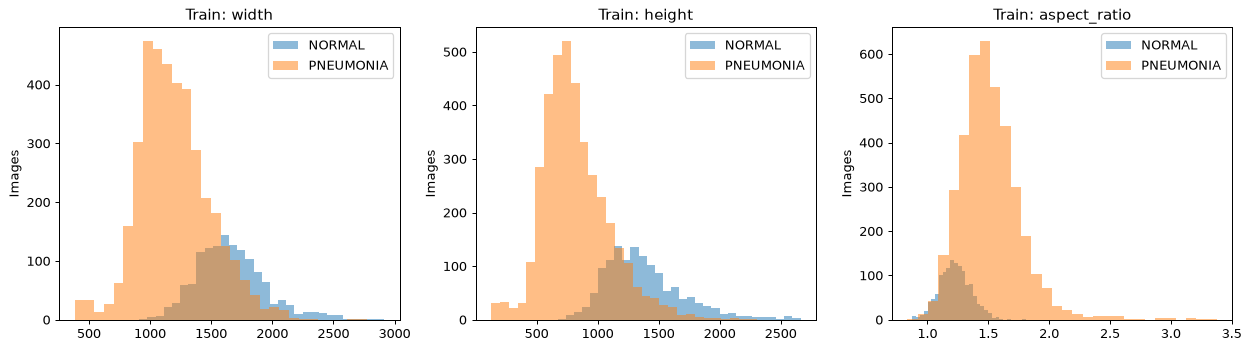

In [7]:
train_meta["aspect_ratio"] = train_meta["width"] / train_meta["height"]
display(train_meta.groupby("class")[["width", "height", "aspect_ratio"]]
        .agg(["min", "median", "mean", "max"]).round(2))
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, feature in zip(axes, ["width", "height", "aspect_ratio"]):
    for cls in CLASSES:
        values = train_meta.loc[train_meta["class"] == cls, feature]
        ax.hist(values, bins=30, alpha=0.5, label=cls)
    ax.set_title(f"Train: {feature}")
    ax.set_ylabel("Images")
    ax.legend()
plt.tight_layout()
plt.show()

### 8. 분할 내부·분할 간 중복 검사
SHA-256으로 파일 바이트가 같은 경우와 디코딩한 원본 픽셀이 같은 경우를 구분한다.
픽셀 해시는 RGB 변환 후 크기와 픽셀 바이트를 함께 사용한다. 동일한 흑백 내용이 RGB로 저장된 경우도 확인할 수 있다.
리사이즈·압축·크롭된 유사 이미지나 같은 환자의 다른 촬영까지 검출하는 검사는 아니다.
테스트는 무결성 감사에만 사용하고 중복을 발견해도 파일을 삭제하거나 다른 분할로 이동하지 않는다.

In [8]:
file_hashes, pixel_hashes = [], []
for row in meta.to_dict("records"):
    file = Path(row["file"])
    file_hashes.append(hashlib.sha256(file.read_bytes()).hexdigest())
    with Image.open(file) as img:
        rgb = img.convert("RGB")
        digest = hashlib.sha256(str(rgb.size).encode() + rgb.tobytes()).hexdigest()
        pixel_hashes.append(digest)
meta["file_hash"] = file_hashes
meta["pixel_hash"] = pixel_hashes

for key in ["file_hash", "pixel_hash"]:
    groups = meta.groupby(key)
    duplicated = groups.size()
    repeated = duplicated[duplicated > 1]
    cross = groups["split"].nunique()
    cross_ids = cross[cross > 1].index
    print(f"{key}: 중복 그룹 {len(repeated)}개, 해당 파일 {int(repeated.sum())}장, 분할 간 중복 그룹 {len(cross_ids)}개")
    for split in ["train", "val", "test"]:
        sizes = meta.loc[meta["split"] == split].groupby(key).size()
        print(f"  {split} 내부: 중복 그룹 {(sizes > 1).sum()}개, 추가 사본 {int((sizes - 1).clip(lower=0).sum())}장")
    if len(cross_ids):
        display(meta.loc[meta[key].isin(cross_ids), ["split", "class", "name", key]].sort_values(key).head(30))
print("서로 다른 라벨을 가진 동일 픽셀 그룹:", int((meta.groupby("pixel_hash")["class"].nunique() > 1).sum()))

file_hash: 중복 그룹 30개, 해당 파일 62장, 분할 간 중복 그룹 0개
  train 내부: 중복 그룹 24개, 추가 사본 26장
  val 내부: 중복 그룹 0개, 추가 사본 0장
  test 내부: 중복 그룹 6개, 추가 사본 6장
pixel_hash: 중복 그룹 30개, 해당 파일 62장, 분할 간 중복 그룹 0개
  train 내부: 중복 그룹 24개, 추가 사본 26장
  val 내부: 중복 그룹 0개, 추가 사본 0장
  test 내부: 중복 그룹 6개, 추가 사본 6장
서로 다른 라벨을 가진 동일 픽셀 그룹: 0


### 9. 검증 16장의 한계
이미지 한 장의 정오가 정확도를 얼마나 바꾸는지 확인한다. 같은 환자 이미지가 포함되면 독립 표본 수도 이미지 수보다 적을 수 있다.

In [9]:
n_val = int(counts.loc["val", "TOTAL"])
print(f"원래 검증 데이터: {n_val}장")
print(f"한 장의 정오가 바뀌면 정확도는 {100 / n_val:.2f}%p 변화")
print("이 검증 정확도만으로 작은 성능 차이나 일반화 성능을 단정하지 않는다.")

원래 검증 데이터: 16장
한 장의 정오가 바뀌면 정확도는 6.25%p 변화
이 검증 정확도만으로 작은 성능 차이나 일반화 성능을 단정하지 않는다.


### 10. 재분할 후보 설정 (원본 유지)
첫 후보는 **기존 train을 약 80:20으로 나누는 그룹 기반 분할**이다. 기존 val은 보조 점검용으로 남긴다.
파일명에서 추출한 환자 추정 ID와 같은 픽셀 해시를 묶어 새 train/val 양쪽에 나뉘지 않도록 한다.
`person숫자`, `IM-숫자`, `NORMAL2-IM-숫자`를 파일명 그룹으로 사용한다. 이는 공식 환자 메타데이터로 검증된 ID가 아니므로 환자 수준 독립성을 보장하지 않는다.
고정 시드로 후보를 한 번 만들고 클래스 분포를 확인한다. 정확한 클래스 비율을 강제하는 층화 분할은 아니다.
현재 train_loader를 덮어쓰지 않으며, 실제 학습에 사용하려면 이 후보 표의 파일 목록으로 별도 Dataset을 구성해야 한다.

In [10]:
from sklearn.model_selection import GroupShuffleSplit

# 환자로 추정되는 파일명 접두어를 추출한다.
def filename_group(name):
    for pattern in [r"^(person\d+)_", r"^(NORMAL2-IM-\d+)-", r"^(IM-\d+)-"]:
        match = re.match(pattern, name)
        if match:
            return match.group(1)
    return Path(name).stem

proposal = meta.loc[meta["split"] == "train"].copy().reset_index(drop=True)
proposal["patient_hint"] = proposal["name"].map(filename_group)
# 환자 추정 ID 또는 픽셀 해시가 같은 파일들을 하나의 그룹으로 합친다.
parent = list(range(len(proposal)))
def find(i):
    while parent[i] != i:
        parent[i] = parent[parent[i]]
        i = parent[i]
    return i
for key in ["patient_hint", "pixel_hash"]:
    first_seen = {}
    for i, value in enumerate(proposal[key]):
        if value in first_seen:
            parent[find(i)] = find(first_seen[value])
        else:
            first_seen[value] = i
proposal["group"] = [find(i) for i in range(len(proposal))]
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
train_idx, val_idx = next(splitter.split(proposal, groups=proposal["group"]))
proposal["candidate_split"] = "train"
proposal.loc[val_idx, "candidate_split"] = "val"
summary = pd.crosstab(proposal["candidate_split"], proposal["class"])
summary["TOTAL"] = summary.sum(axis=1)
summary["PNEUMONIA_pct"] = summary["PNEUMONIA"] / summary["TOTAL"] * 100
display(summary.round(2))
assert set(proposal.loc[train_idx, "group"]).isdisjoint(proposal.loc[val_idx, "group"])
assert set(proposal.loc[train_idx, "pixel_hash"]).isdisjoint(proposal.loc[val_idx, "pixel_hash"])
print("후보 분할의 그룹·동일 픽셀 중복 없음. 실제 로더에는 아직 적용하지 않았습니다.")

class,NORMAL,PNEUMONIA,TOTAL,PNEUMONIA_pct
candidate_split,,,,
train,1062,3075,4137,74.33
val,279,800,1079,74.14


후보 분할의 그룹·동일 픽셀 중복 없음. 실제 로더에는 아직 적용하지 않았습니다.


### 11. 테스트 보존과 다음 단계
- 테스트 파일은 수정·이동·삭제하지 않았으며 모델 선택·증강 선택에 테스트 성능을 사용하지 않는다.
- 재분할 후보를 사용할 경우 모든 모델에 동일한 train/val 파일 목록을 사용한다.
- 분할 간 중복이 검출되면 해당 목록과 처리 방침을 먼저 확정하고 학습한다. 테스트를 임의로 정제해 높은 점수를 만드는 것은 피한다.
- 최종 테스트는 학습 방식·하이퍼파라미터·선택 지표를 확정한 후 수행한다.
- 검증 Accuracy 또는 F1 중 저장 기준을 사전에 정하고 나머지 지표도 함께 기록한다.
- 다음 단계는 EDA 관찰을 바탕으로 전처리 후보를 정하고 변환 전후 이미지를 비교하는 것이다.

**이번 실행 결과 요약**
- 학습 5,216장(정상 1,341 / 폐렴 3,875), 검증 16장(8 / 8), 테스트 624장(234 / 390).
- 학습 다수 클래스는 폐렴이며 학습 기준선은 약 74.29%다. 같은 예측 규칙의 검증 기준선은 50%, 테스트 기준선은 62.5%다.
- 5,856장 모두 읽기 성공. 학습 원본은 L 4,933장, RGB 283장이다.
- 학습 원본 크기 중앙값(너비×높이): 정상 1640×1328, 폐렴 1168×776. 두 중앙값은 각각의 축을 요약한 값이며 실제 한 이미지의 크기라는 뜻은 아니다.
- 동일 파일·픽셀 기준으로 학습 내부 24그룹(추가 사본 26장), 테스트 내부 6그룹(추가 사본 6장). 분할 간 동일 이미지 그룹은 0개다. 유사 이미지·환자 중복까지 없다는 뜻은 아니다.
- 그룹 기반 후보: 학습 4,137장(정상 1,062 / 폐렴 3,075), 검증 1,079장(279 / 800). 기존 val 16장은 별도 보조 점검용으로 남긴다.
- 이 후보는 원본 파일과 기존 로더를 바꾸지 않는다. 실제 학습 전 환자 추정 그룹의 타당성·클래스 비율을 검토하고 분할을 확정한다.
